LOADING YELP DATASET FILES
Loading data/json/yelp_academic_dataset_business.json...
  Processed 5,000 records...
  Processed 10,000 records...
  Processed 15,000 records...
✓ Successfully loaded 20,000 records from data/json/yelp_academic_dataset_business.json
Loading data/json/yelp_academic_dataset_user.json...
  Processed 5,000 records...
  Processed 10,000 records...
✓ Successfully loaded 15,000 records from data/json/yelp_academic_dataset_user.json
Loading data/json/yelp_academic_dataset_review.json...
  Processed 5,000 records...
✓ Successfully loaded 10,000 records from data/json/yelp_academic_dataset_review.json
Loading data/json/yelp_academic_dataset_tip.json...
✓ Successfully loaded 5,000 records from data/json/yelp_academic_dataset_tip.json
Loading data/json/yelp_academic_dataset_checkin.json...
✓ Successfully loaded 3,000 records from data/json/yelp_academic_dataset_checkin.json

DATASET SUMMARY
Businesses   : 20,000 records
             Columns: ['business_id', 'name', 'add

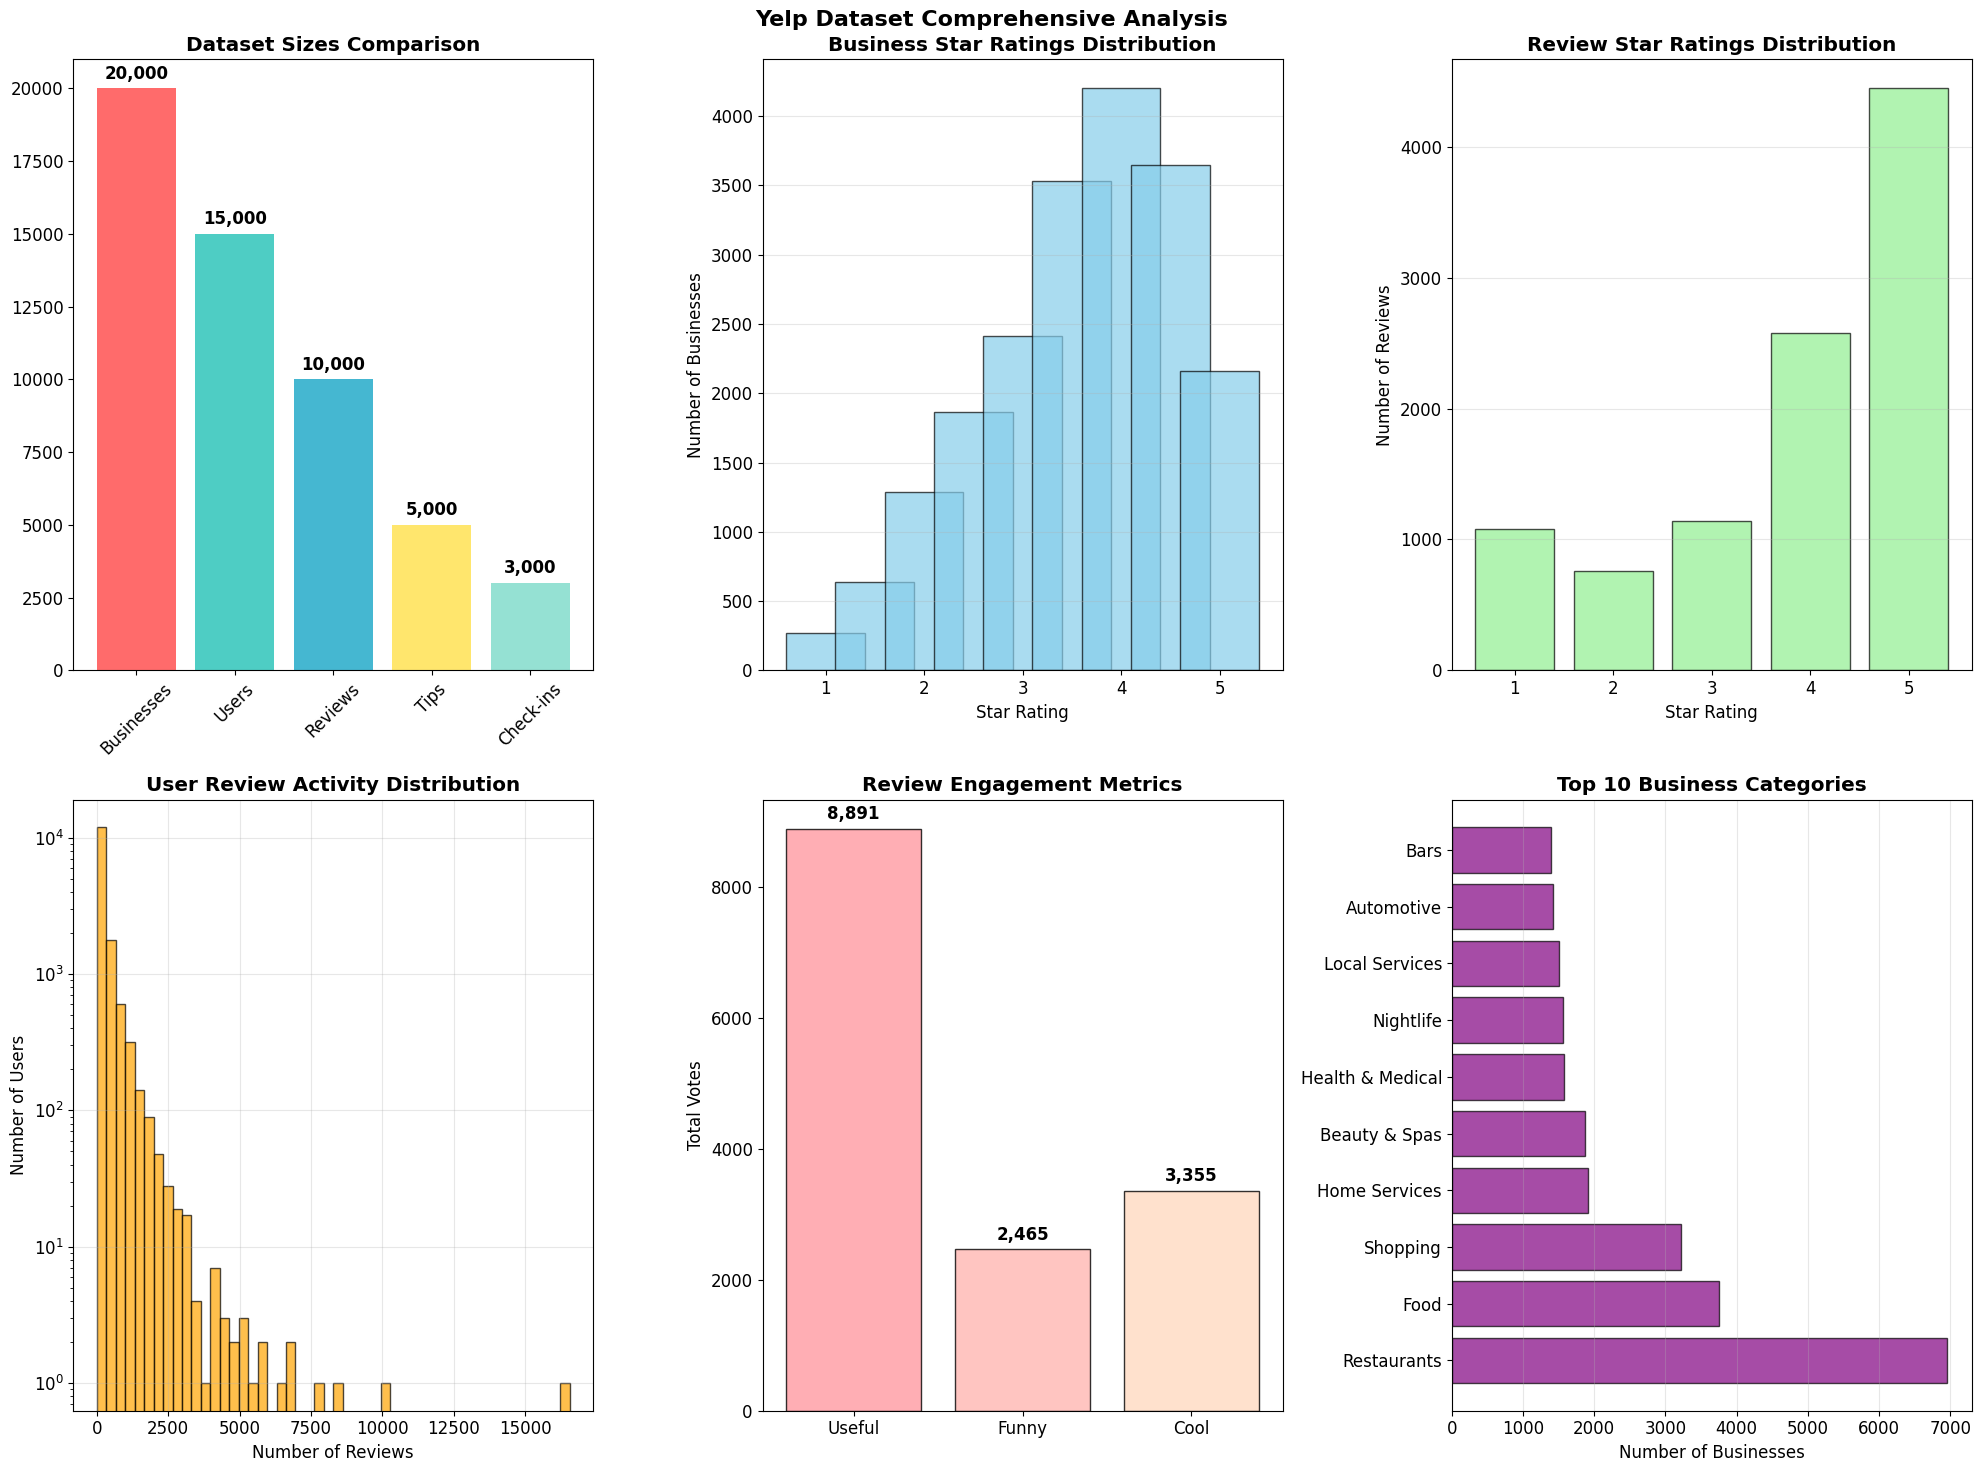


DATASET CONNECTIONS ANALYSIS
//
📊 Business coverage in reviews: 19.7%
   (3,930 businesses reviewed out of 20,000 total)
//
👥 User coverage in reviews: 63.1%
   (9,472 users wrote reviews out of 15,000 total)
//


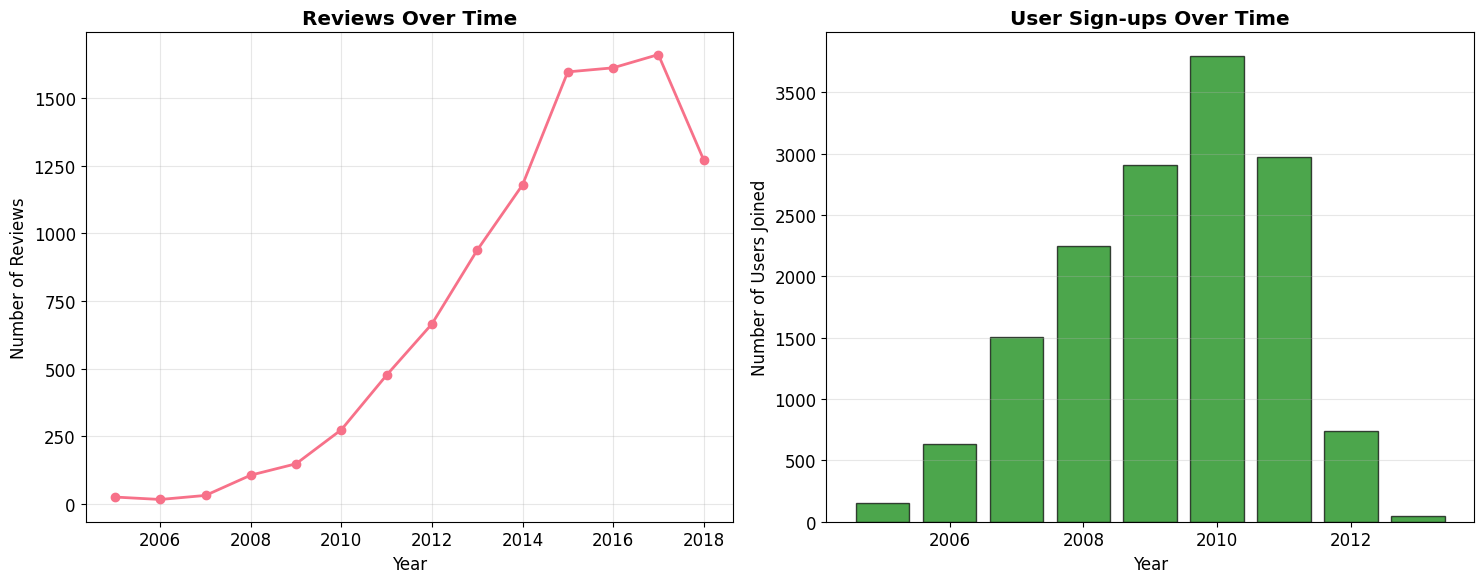


REVIEW ENGAGEMENT CORRELATIONS
Correlation between engagement metrics:
        useful  funny   cool
useful   1.000  0.426  0.637
funny    0.426  1.000  0.521
cool     0.637  0.521  1.000


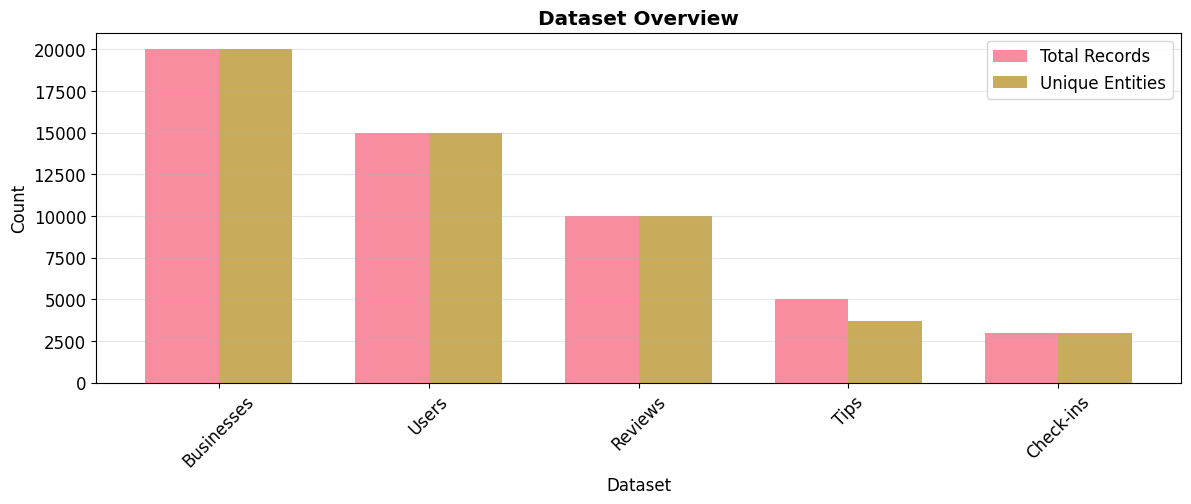

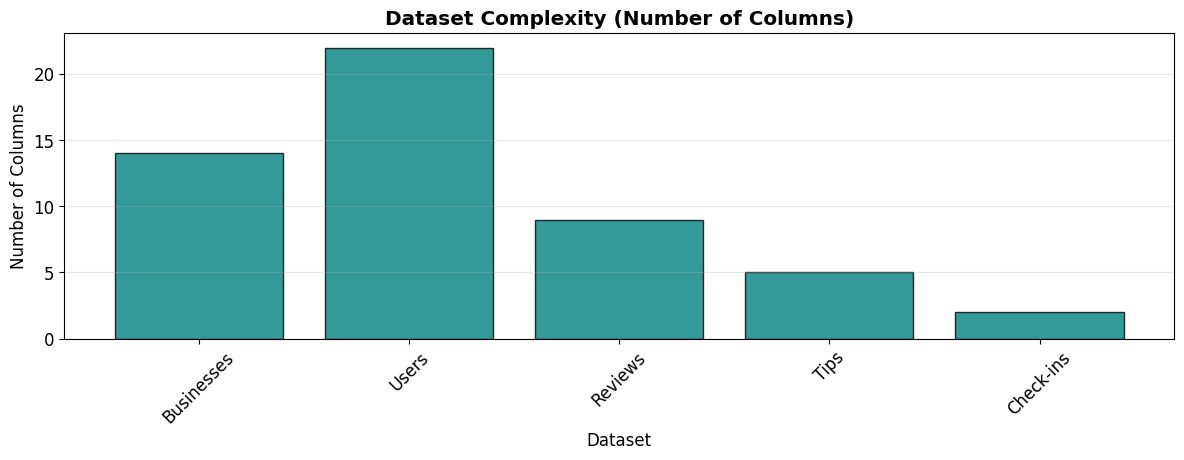


ANALYSIS COMPLETE!

📊 Total data loaded: 53,000 records


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

def load_json_lines_safe(file_path, sample_size=10000, chunksize=1000):
    """Safely load JSON lines files with chunking"""
    try:
        print(f"Loading {file_path}...")
        chunks = pd.read_json(file_path, lines=True, chunksize=chunksize)
        data = []
        total_records = 0
        
        for i, chunk in enumerate(chunks):
            data.append(chunk)
            total_records += len(chunk)
            if total_records >= sample_size:
                break
            if (i + 1) % 5 == 0:
                print(f"  Processed {total_records:,} records...")
        
        result = pd.concat(data, ignore_index=True)
        print(f"✓ Successfully loaded {len(result):,} records from {file_path}")
        return result
        
    except Exception as e:
        print(f"✗ Error loading {file_path}: {e}")
        # Try manual line-by-line loading as backup
        try:
            data = []
            with open(file_path, 'r', encoding='utf-8') as f:
                for i, line in enumerate(f):
                    if i >= sample_size:
                        break
                    data.append(json.loads(line))
            result = pd.DataFrame(data)
            print(f"✓ Successfully loaded {len(result):,} records (manual method)")
            return result
        except:
            print(f"✗ Failed to load {file_path}")
            return None

# Load all datasets with safe chunking
print("=" * 60)
print("LOADING YELP DATASET FILES")
print("=" * 60)

# Load each dataset
business_df = load_json_lines_safe('data/json/yelp_academic_dataset_business.json', 20000)
user_df = load_json_lines_safe('data/json/yelp_academic_dataset_user.json', 15000)
review_df = load_json_lines_safe('data/json/yelp_academic_dataset_review.json', 10000)
tip_df = load_json_lines_safe('data/json/yelp_academic_dataset_tip.json', 5000)
checkin_df = load_json_lines_safe('data/json/yelp_academic_dataset_checkin.json', 3000)

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

datasets = {
    'Businesses': business_df,
    'Users': user_df,
    'Reviews': review_df,
    'Tips': tip_df,
    'Check-ins': checkin_df
}

for name, df in datasets.items():
    if df is not None:
        print(f"{name:12} : {len(df):>6,} records")
        if len(df) > 0:
            print(f"             Columns: {list(df.columns)}")
    else:
        print(f"{name:12} : Failed to load")

print("\n" + "=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

for name, df in datasets.items():
    if df is not None:
        missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
        print(f"\n{name} - Missing values (%):")
        for col, percent in missing_percent.items():
            if percent > 0:
                print(f"  {col:20} : {percent:>6}%")

# Create comprehensive visualizations
print("\n" + "=" * 60)
print("CREATING VISUALIZATIONS")
print("=" * 60)

# 1. Dataset Relationship Diagram
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
fig.suptitle('Yelp Dataset Comprehensive Analysis', fontsize=16, fontweight='bold')

# Dataset sizes comparison
ax1 = axes[0, 0]
if all(df is not None for df in datasets.values()):
    sizes = [len(df) for df in datasets.values()]
    names = list(datasets.keys())
    bars = ax1.bar(names, sizes, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFE66D', '#95E1D3'])
    ax1.set_title('Dataset Sizes Comparison', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(sizes)*0.01,
                f'{height:,}', ha='center', va='bottom', fontweight='bold')

# Business star ratings
ax2 = axes[0, 1]
if business_df is not None and 'stars' in business_df.columns:
    star_counts = business_df['stars'].value_counts().sort_index()
    ax2.bar(star_counts.index, star_counts.values, alpha=0.7, color='skyblue', edgecolor='black')
    ax2.set_xlabel('Star Rating')
    ax2.set_ylabel('Number of Businesses')
    ax2.set_title('Business Star Ratings Distribution', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

# Review star ratings
ax3 = axes[0, 2]
if review_df is not None and 'stars' in review_df.columns:
    review_stars = review_df['stars'].value_counts().sort_index()
    ax3.bar(review_stars.index, review_stars.values, alpha=0.7, color='lightgreen', edgecolor='black')
    ax3.set_xlabel('Star Rating')
    ax3.set_ylabel('Number of Reviews')
    ax3.set_title('Review Star Ratings Distribution', fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)

# User review count distribution
ax4 = axes[1, 0]
if user_df is not None and 'review_count' in user_df.columns:
    user_df['review_count'].hist(bins=50, ax=ax4, color='orange', alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Number of Reviews')
    ax4.set_ylabel('Number of Users')
    ax4.set_title('User Review Activity Distribution', fontweight='bold')
    ax4.set_yscale('log')
    ax4.grid(alpha=0.3)

# Review engagement metrics
ax5 = axes[1, 1]
if review_df is not None:
    engagement = {
        'Useful': review_df['useful'].sum() if 'useful' in review_df.columns else 0,
        'Funny': review_df['funny'].sum() if 'funny' in review_df.columns else 0,
        'Cool': review_df['cool'].sum() if 'cool' in review_df.columns else 0
    }
    colors = ['#FF9AA2', '#FFB7B2', '#FFDAC1']
    ax5.bar(engagement.keys(), engagement.values(), color=colors, alpha=0.8, edgecolor='black')
    ax5.set_title('Review Engagement Metrics', fontweight='bold')
    ax5.set_ylabel('Total Votes')
    for i, (label, value) in enumerate(engagement.items()):
        ax5.text(i, value + max(engagement.values())*0.01, f'{value:,}', 
                ha='center', va='bottom', fontweight='bold')
print("//")
# Business categories word cloud (simplified)
ax6 = axes[1, 2]
if business_df is not None and 'categories' in business_df.columns:
    all_categories = []
    for cats in business_df['categories'].dropna():
        if isinstance(cats, str):
            all_categories.extend([cat.strip() for cat in cats.split(',')])
    
    category_counts = Counter(all_categories)
    top_categories = category_counts.most_common(10)
    
    categories, counts = zip(*top_categories)
    y_pos = np.arange(len(categories))
    
    ax6.barh(y_pos, counts, color='purple', alpha=0.7, edgecolor='black')
    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(categories)
    ax6.set_xlabel('Number of Businesses')
    ax6.set_title('Top 10 Business Categories', fontweight='bold')
    ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Advanced Analysis and Connections
print("\n" + "=" * 60)
print("DATASET CONNECTIONS ANALYSIS")
print("=" * 60)
print("//")
# Check common columns and connections
if business_df is not None and review_df is not None:
    unique_businesses_in_reviews = review_df['business_id'].nunique()
    unique_businesses_total = business_df['business_id'].nunique()
    coverage = (unique_businesses_in_reviews / unique_businesses_total) * 100
    
    print(f"📊 Business coverage in reviews: {coverage:.1f}%")
    print(f"   ({unique_businesses_in_reviews:,} businesses reviewed out of {unique_businesses_total:,} total)")
print("//")
if user_df is not None and review_df is not None:
    unique_users_in_reviews = review_df['user_id'].nunique()
    unique_users_total = user_df['user_id'].nunique()
    user_coverage = (unique_users_in_reviews / unique_users_total) * 100
    
    print(f"👥 User coverage in reviews: {user_coverage:.1f}%")
    print(f"   ({unique_users_in_reviews:,} users wrote reviews out of {unique_users_total:,} total)")

# 3. Temporal Analysis (if date columns exist)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

print("//")

# Review dates
ax1 = axes[0]
if review_df is not None and 'date' in review_df.columns:
    review_df['date'] = pd.to_datetime(review_df['date'])
    reviews_by_year = review_df['date'].dt.year.value_counts().sort_index()
    ax1.plot(reviews_by_year.index, reviews_by_year.values, marker='o', linewidth=2)
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Number of Reviews')
    ax1.set_title('Reviews Over Time', fontweight='bold')
    ax1.grid(True, alpha=0.3)

# User join dates
ax2 = axes[1]
if user_df is not None and 'yelping_since' in user_df.columns:
    user_df['yelping_since'] = pd.to_datetime(user_df['yelping_since'])
    users_by_year = user_df['yelping_since'].dt.year.value_counts().sort_index()
    ax2.bar(users_by_year.index, users_by_year.values, alpha=0.7, color='green', edgecolor='black')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Number of Users Joined')
    ax2.set_title('User Sign-ups Over Time', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Correlation Analysis
if review_df is not None:
    print("\n" + "=" * 60)
    print("REVIEW ENGAGEMENT CORRELATIONS")
    print("=" * 60)
    
    # Calculate correlations between engagement metrics
    engagement_cols = ['useful', 'funny', 'cool']
    if all(col in review_df.columns for col in engagement_cols):
        correlation_matrix = review_df[engagement_cols].corr()
        print("Correlation between engagement metrics:")
        print(correlation_matrix.round(3))

# 5. Final Summary Dashboard
plt.figure(figsize=(14, 10))

# Create a comprehensive summary
summary_data = []
for name, df in datasets.items():
    if df is not None:
        summary_data.append({
            'Dataset': name,
            'Total Records': len(df),
            'Unique Entities': df.iloc[:, 0].nunique(),  # First column is usually ID
            'Columns': len(df.columns)
        })

summary_df = pd.DataFrame(summary_data)

# Plot summary
plt.subplot(2, 1, 1)
x = np.arange(len(summary_df))
width = 0.35
plt.bar(x - width/2, summary_df['Total Records'], width, label='Total Records', alpha=0.8)
plt.bar(x + width/2, summary_df['Unique Entities'], width, label='Unique Entities', alpha=0.8)
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.title('Dataset Overview', fontweight='bold')
plt.xticks(x, summary_df['Dataset'], rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


# Plot column counts
plt.subplot(2, 1, 2)
plt.bar(summary_df['Dataset'], summary_df['Columns'], color='teal', alpha=0.8, edgecolor='black')
plt.xlabel('Dataset')
plt.ylabel('Number of Columns')
plt.title('Dataset Complexity (Number of Columns)', fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE!")

print(f"\n📊 Total data loaded: {sum(len(df) for df in datasets.values() if df is not None):,} records")

In [7]:
image_df = load_json_lines_safe('photos.json', sample_size=200000)


Loading photos.json...
  Processed 5,000 records...
  Processed 10,000 records...
  Processed 15,000 records...
  Processed 20,000 records...
  Processed 25,000 records...
  Processed 30,000 records...
  Processed 35,000 records...
  Processed 40,000 records...
  Processed 45,000 records...
  Processed 50,000 records...
  Processed 55,000 records...
  Processed 60,000 records...
  Processed 65,000 records...
  Processed 70,000 records...
  Processed 75,000 records...
  Processed 80,000 records...
  Processed 85,000 records...
  Processed 90,000 records...
  Processed 95,000 records...
  Processed 100,000 records...
  Processed 105,000 records...
  Processed 110,000 records...
  Processed 115,000 records...
  Processed 120,000 records...
  Processed 125,000 records...
  Processed 130,000 records...
  Processed 135,000 records...
  Processed 140,000 records...
  Processed 145,000 records...
  Processed 150,000 records...
  Processed 155,000 records...
  Processed 160,000 records...
  Pro

In [8]:
# Get all business_ids from your subset
subset_business_ids = set(business_df['business_id'])

# Filter images for the
# subset businesses
subset_images = image_df[image_df['business_id'].isin(subset_business_ids)]

print(f"Total images for subset businesses: {len(subset_images):,}")
print(f"Number of subset businesses with at least one image: {subset_images['business_id'].nunique():,}")


Total images for subset businesses: 27,050
Number of subset businesses with at least one image: 4,917


In [9]:
image_df = load_json_lines_safe('photos.json', sample_size=200000)


Loading photos.json...
  Processed 5,000 records...
  Processed 10,000 records...
  Processed 15,000 records...
  Processed 20,000 records...
  Processed 25,000 records...
  Processed 30,000 records...
  Processed 35,000 records...
  Processed 40,000 records...
  Processed 45,000 records...
  Processed 50,000 records...
  Processed 55,000 records...
  Processed 60,000 records...
  Processed 65,000 records...
  Processed 70,000 records...
  Processed 75,000 records...
  Processed 80,000 records...
  Processed 85,000 records...
  Processed 90,000 records...
  Processed 95,000 records...
  Processed 100,000 records...
  Processed 105,000 records...
  Processed 110,000 records...
  Processed 115,000 records...
  Processed 120,000 records...
  Processed 125,000 records...
  Processed 130,000 records...
  Processed 135,000 records...
  Processed 140,000 records...
  Processed 145,000 records...
  Processed 150,000 records...
  Processed 155,000 records...
  Processed 160,000 records...
  Pro

Total images for subset businesses: 27,050
Number of subset businesses with at least one image: 4,917


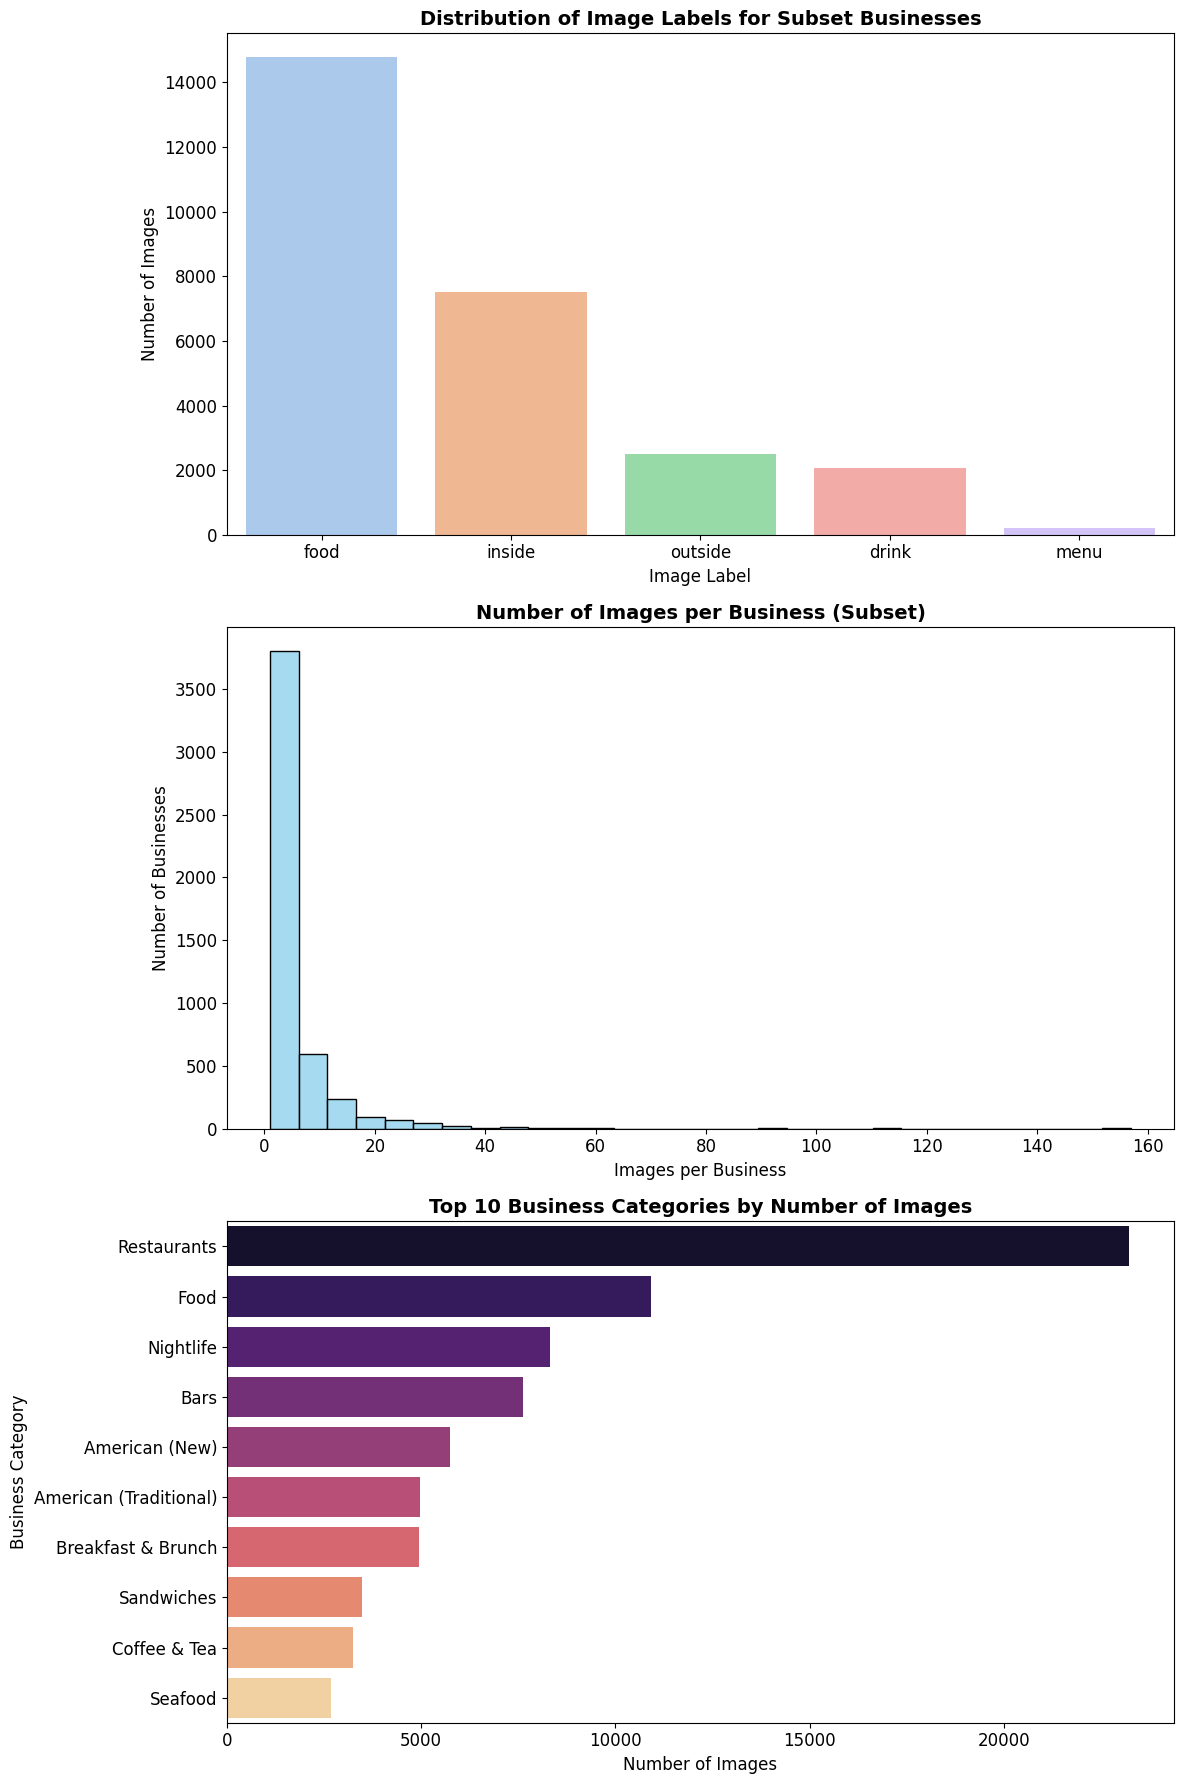

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Merge photos with subset businesses
subset_business_ids = set(business_df['business_id'])
photos_subset = image_df[image_df['business_id'].isin(subset_business_ids)]

print(f"Total images for subset businesses: {len(photos_subset):,}")
print(f"Number of subset businesses with at least one image: {photos_subset['business_id'].nunique():,}")

# Prepare top business categories
business_photos = business_df[['business_id', 'categories']].merge(
    photos_subset[['business_id']], on='business_id', how='inner'
)
all_categories = []
for cats in business_photos['categories'].dropna():
    if isinstance(cats, str):
        all_categories.extend([cat.strip() for cat in cats.split(',')])
top_categories = Counter(all_categories).most_common(10)
categories, counts = zip(*top_categories)

# Create a single figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

# 1. Image label distribution
sns.countplot(data=photos_subset, x='label', order=photos_subset['label'].value_counts().index,
              palette='pastel', ax=axes[0])
axes[0].set_title('Distribution of Image Labels for Subset Businesses', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Image Label')
axes[0].set_ylabel('Number of Images')

# 2. Images per business
images_per_business = photos_subset.groupby('business_id').size()
sns.histplot(images_per_business, bins=30, color='skyblue', edgecolor='black', ax=axes[1])
axes[1].set_title('Number of Images per Business (Subset)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Images per Business')
axes[1].set_ylabel('Number of Businesses')

# 3. Top business categories with images
sns.barplot(x=list(counts), y=list(categories), palette='magma', ax=axes[2])
axes[2].set_title('Top 10 Business Categories by Number of Images', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Images')
axes[2].set_ylabel('Business Category')

# Save the full figure as one image
plt.tight_layout()
plt.savefig("subset_images_overview.png", dpi=300)
plt.show()

In [11]:
# Explore business categories in more detail
if business_df is not None and 'categories' in business_df.columns:
    all_categories = []
    for cats in business_df['categories'].dropna():
        if isinstance(cats, str):
            all_categories.extend([cat.strip() for cat in cats.split(',')])
    
    unique_categories = set(all_categories)
    print("\n" + "=" * 60)
    print("CATEGORY ANALYSIS")
    print("=" * 60)
    print(f"Total unique categories: {len(unique_categories):,}")
    
    # Top 20 categories
    category_counts = Counter(all_categories).most_common(20)
    print("\nTop 20 business categories:")
    for cat, count in category_counts:
        print(f"  {cat:25} {count:,}")



CATEGORY ANALYSIS
Total unique categories: 1,145

Top 20 business categories:
  Restaurants               6,953
  Food                      3,753
  Shopping                  3,214
  Home Services             1,907
  Beauty & Spas             1,876
  Health & Medical          1,570
  Nightlife                 1,559
  Local Services            1,511
  Automotive                1,424
  Bars                      1,400
  Event Planning & Services 1,356
  Sandwiches                1,085
  Active Life               1,073
  American (Traditional)    1,034
  Pizza                     960
  Coffee & Tea              863
  Fast Food                 859
  American (New)            840
  Breakfast & Brunch        835
  Home & Garden             775


In [12]:
import pandas as pd
import json

# Load a small sample of the business JSON
file_path = 'data/json/yelp_academic_dataset_business.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = [json.loads(next(f)) for _ in range(5)]  # read first 5 records as a sample

df = pd.DataFrame(data)
print("Business dataset columns:")
print(df.columns.tolist())


Business dataset columns:
['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']


In [13]:
import pandas as pd
import json

# Load a small sample of the business JSON
file_path = 'data/json/yelp_academic_dataset_user.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = [json.loads(next(f)) for _ in range(5)]  # read first 5 records as a sample

df = pd.DataFrame(data)
print("User dataset columns:")
print(df.columns.tolist())


User dataset columns:
['user_id', 'name', 'review_count', 'yelping_since', 'useful', 'funny', 'cool', 'elite', 'friends', 'fans', 'average_stars', 'compliment_hot', 'compliment_more', 'compliment_profile', 'compliment_cute', 'compliment_list', 'compliment_note', 'compliment_plain', 'compliment_cool', 'compliment_funny', 'compliment_writer', 'compliment_photos']


In [14]:
import pandas as pd
import json

# Load a small sample of the business JSON
file_path = 'data/json/yelp_academic_dataset_review.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = [json.loads(next(f)) for _ in range(5)]  # read first 5 records as a sample

df = pd.DataFrame(data)
print("Review dataset columns:")
print(df.columns.tolist())

Review dataset columns:
['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']


In [15]:
import pandas as pd
import json

# Load a small sample of the business JSON
file_path = 'data/json/yelp_academic_dataset_tip.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = [json.loads(next(f)) for _ in range(5)]  # read first 5 records as a sample

df = pd.DataFrame(data)
print("Tip dataset columns:")
print(df.columns.tolist())


Tip dataset columns:
['user_id', 'business_id', 'text', 'date', 'compliment_count']


In [16]:
import pandas as pd
import json

# Load a small sample of the business JSON
file_path = 'data/json/yelp_academic_dataset_checkin.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = [json.loads(next(f)) for _ in range(5)]  # read first 5 records as a sample

df = pd.DataFrame(data)
print("Checkin dataset columns:")
print(df.columns.tolist())


Checkin dataset columns:
['business_id', 'date']


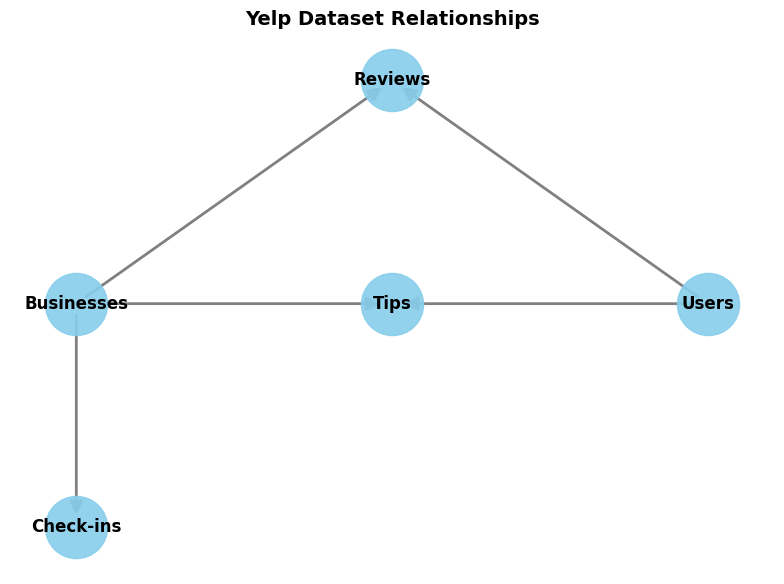

In [17]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes (datasets)
datasets = ['Businesses', 'Users', 'Reviews', 'Tips', 'Check-ins']
G.add_nodes_from(datasets)

# Add edges to show relationships via IDs
edges = [
    ('Businesses', 'Reviews'),
    ('Businesses', 'Tips'),
    ('Businesses', 'Check-ins'),
    ('Users', 'Reviews'),
    ('Users', 'Tips')
]
G.add_edges_from(edges)

# Plot settings
plt.figure(figsize=(8,6))
pos = {
    'Businesses': (0, 1),
    'Users': (2, 1),
    'Reviews': (1, 2),
    'Tips': (1, 1),
    'Check-ins': (0, 0)
}

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue', alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, edge_color='gray', width=2)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

plt.title("Yelp Dataset Relationships", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()

# Save figure
plt.savefig("plotI_relationships.png", dpi=300)
plt.show()


In [18]:
# From the image files themselves:
image_metadata = {
    'file_name': 'ZZzKKkxnO3XdEHbCfojGXw.jpg',
    'file_size': 1024,          # bytes
    'dimensions': (1200, 800),  # width x height
    'format': 'JPEG',           # file format
    'aspect_ratio': 1.5,        # width/height
    'file_created': '2023-01-15',  # creation date
}

=== IMAGE METADATA ANALYSIS ===
Total images: 3
Unique businesses with images: 2
Unique users who posted images: 3
Image categories: {'food': 1, 'inside': 1, 'menu': 1}

✅ Successfully connected 3 images with business data
✅ Successfully connected 3 images with user data

CREATING IMAGE DATA VISUALIZATIONS


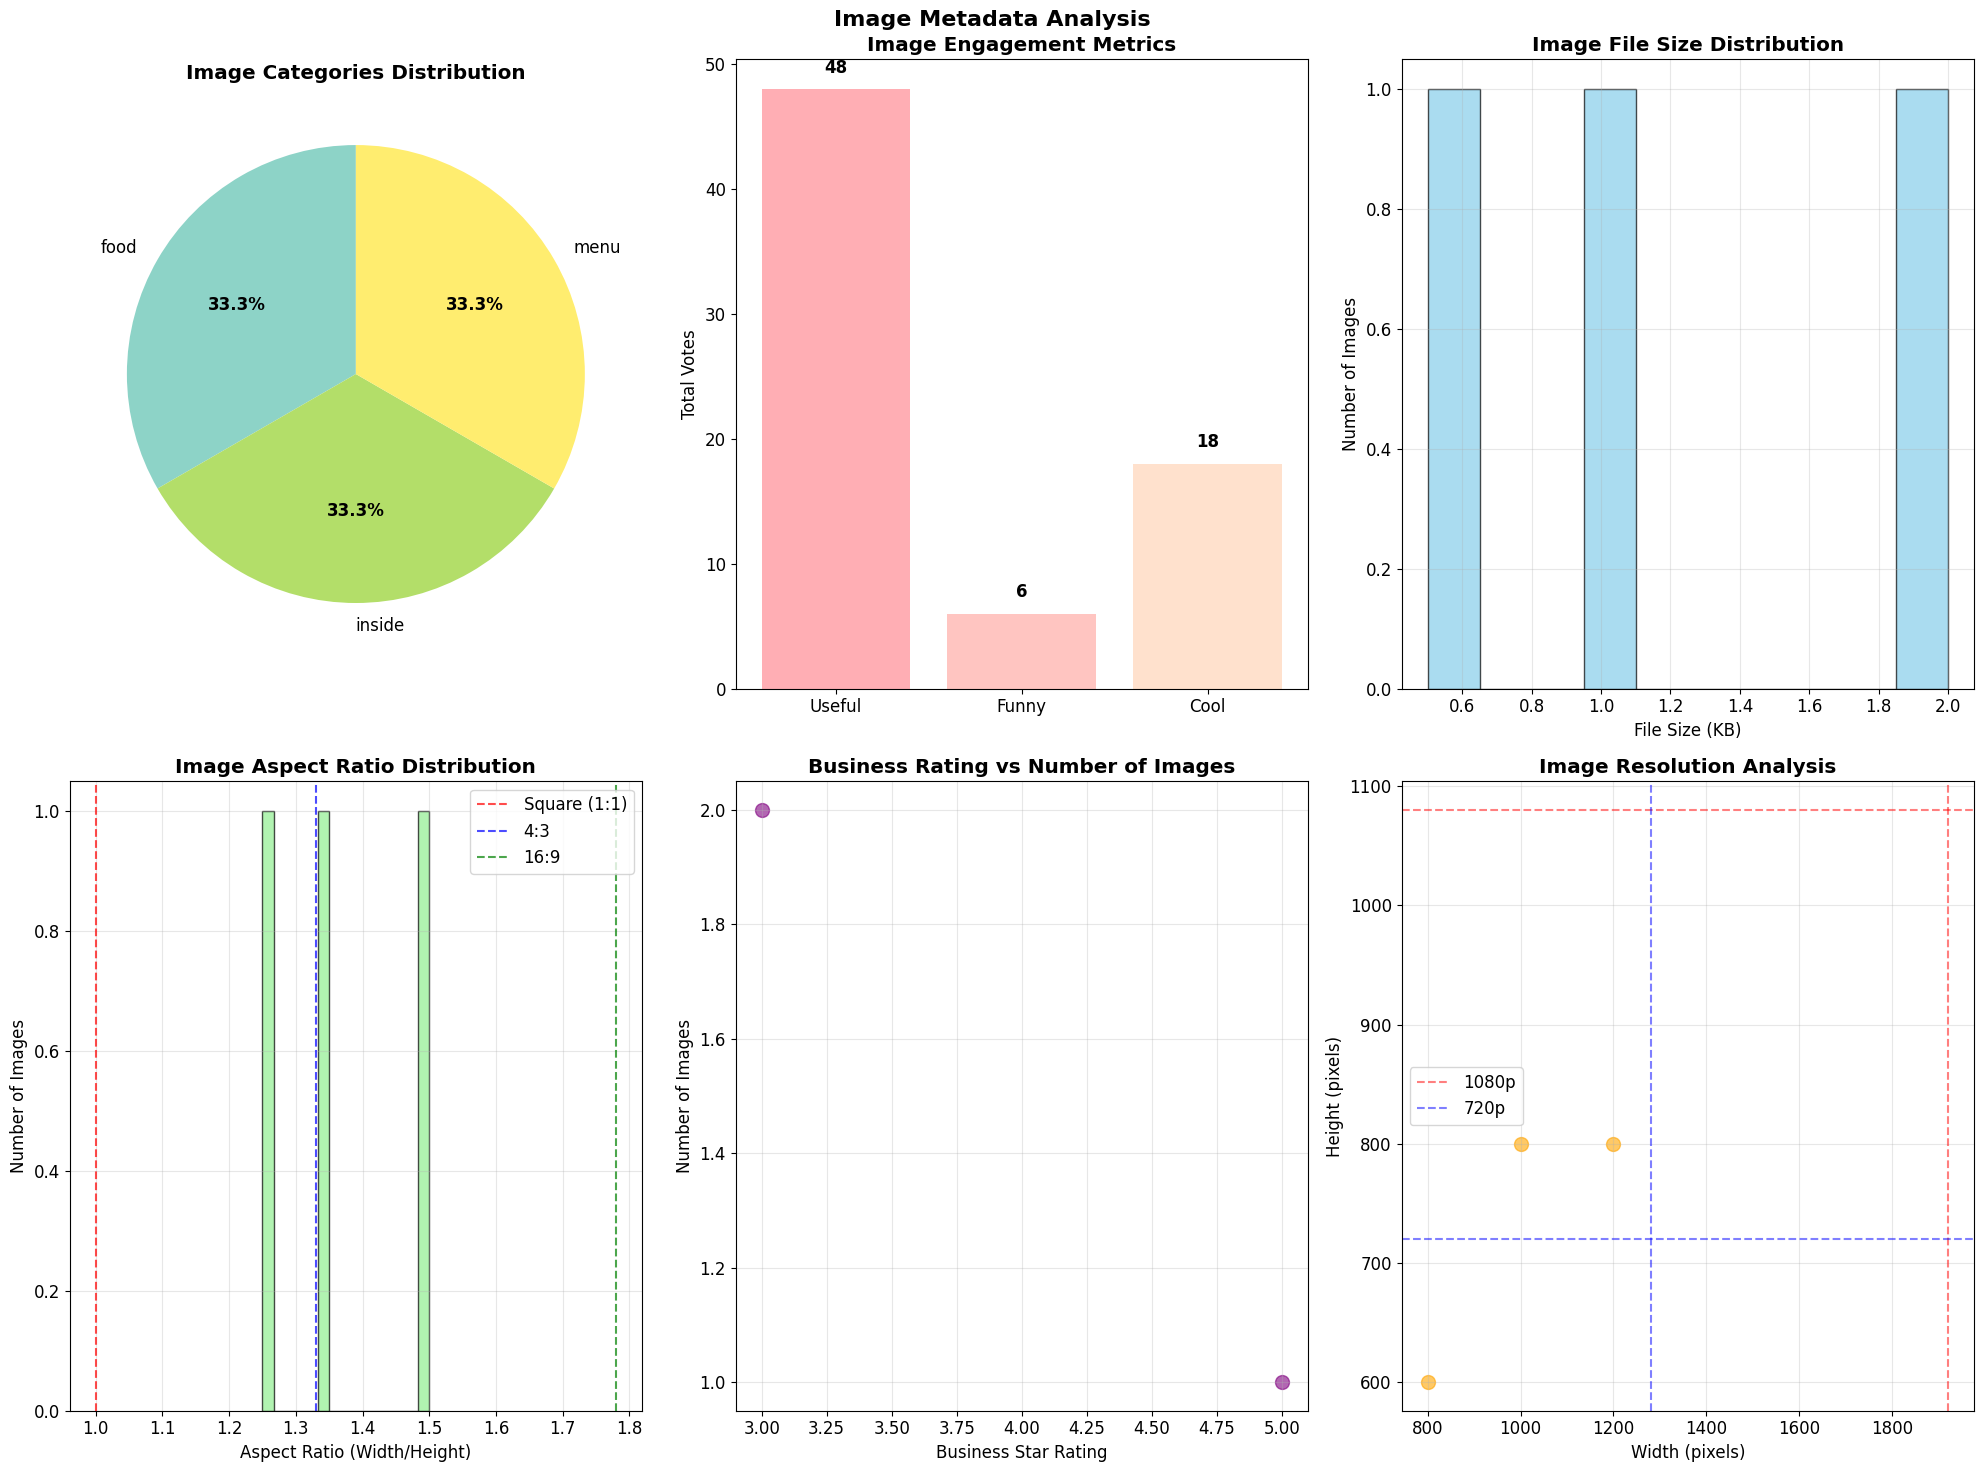


IMAGE-BUSINESS CORRELATION ANALYSIS
Businesses with images: 2
Businesses without images: 19,998

📊 Average rating - With images: 4.00 stars
📊 Average rating - Without images: 3.60 stars
📈 Average reviews - With images: 156.5 reviews
📈 Average reviews - Without images: 46.1 reviews


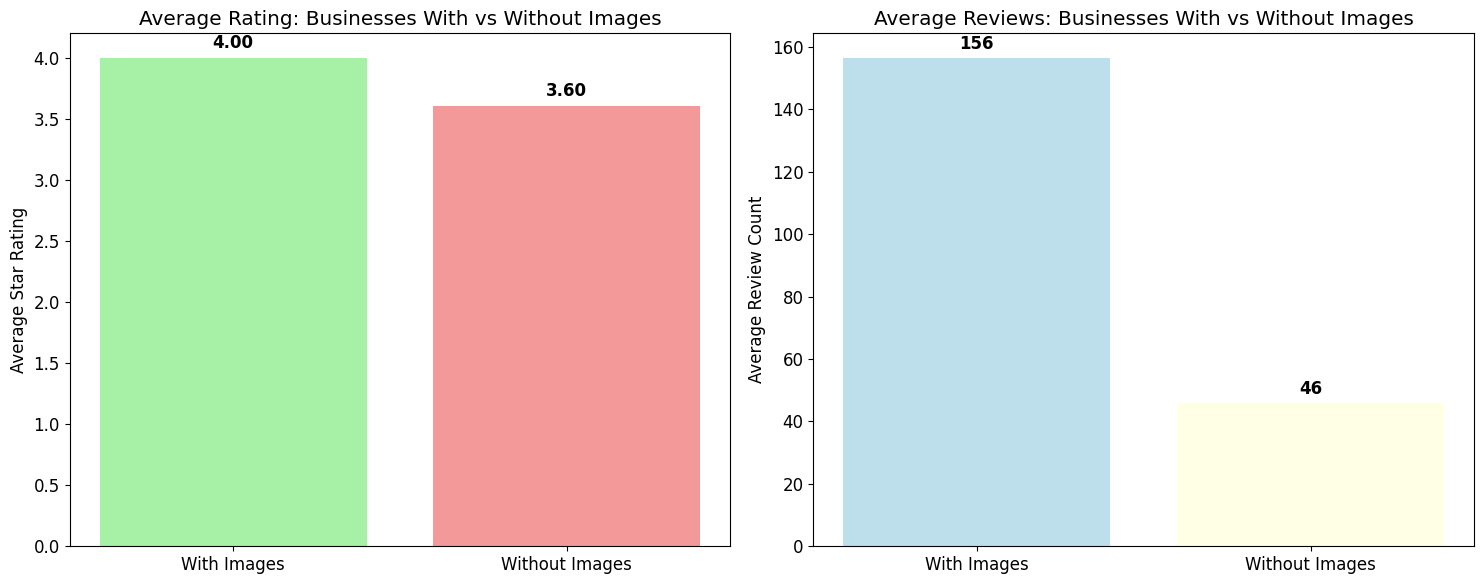


IMAGE CONTENT ANALYSIS SUMMARY
Image Content Distribution:
  Food Images         :   1 images (33.3%)
  Interior Images     :   1 images (33.3%)
  Menu Images         :   1 images (33.3%)

👥 User Engagement with Images:
   Most active user: mh_-eMZ6... with 1 images
   Average images per user: 1.0
   Users who posted images: 3

ANALYSIS COMPLETE!
🎯 Image Metadata Analysis Summary:
   📸 Total images analyzed: 3
   🏢 Connected to 2 businesses
   👥 Connected to 3 users
   📊 Multiple visualizations created
   🔗 Integrated with business and user data


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Assume we have your existing data loaded
# business_df, user_df, review_df, tip_df, checkin_df

# Let's create sample image metadata (replace with your actual data)
image_metadata = {
    'file_name': 'ZZzKKkxnO3XdEHbCfojGXw.jpg',
    'file_size': 1024,          
    'dimensions': (1200, 800),  
    'format': 'JPEG',           
    'aspect_ratio': 1.5,        
    'file_created': '2023-01-15',
    'business_id': 'XQfwVwDr-v0ZS3_CbbE5Xw',  # Added business_id connection
    'user_id': 'mh_-eMZ6K5RLWhZyISBhwA',      # Added user_id connection
    'label': 'food',                          # Added category label
    'votes': {'useful': 15, 'funny': 3, 'cool': 8}  # Added engagement
}

# For multiple images, you'd have a list of such dictionaries
# Let's create sample multiple images for demonstration
sample_images = [
    {
        'file_name': 'ZZzKKkxnO3XdEHbCfojGXw.jpg',
        'business_id': 'XQfwVwDr-v0ZS3_CbbE5Xw',
        'user_id': 'mh_-eMZ6K5RLWhZyISBhwA',
        'label': 'food',
        'votes': {'useful': 15, 'funny': 3, 'cool': 8},
        'file_size': 1024,
        'dimensions': (1200, 800)
    },
    {
        'file_name': 'abc123photo.jpg',
        'business_id': 'XQfwVwDr-v0ZS3_CbbE5Xw', 
        'user_id': 'user456',
        'label': 'inside',
        'votes': {'useful': 8, 'funny': 1, 'cool': 4},
        'file_size': 2048,
        'dimensions': (800, 600)
    },
    {
        'file_name': 'def456photo.jpg',
        'business_id': '7ATYjTIgM3jUlt4UM3IypQ',
        'user_id': 'user789',
        'label': 'menu',
        'votes': {'useful': 25, 'funny': 2, 'cool': 6},
        'file_size': 512,
        'dimensions': (1000, 800)
    }
]

# Convert to DataFrame
images_df = pd.DataFrame(sample_images)

# Expand the votes dictionary into separate columns
images_df['useful_votes'] = images_df['votes'].apply(lambda x: x.get('useful', 0))
images_df['funny_votes'] = images_df['votes'].apply(lambda x: x.get('funny', 0))
images_df['cool_votes'] = images_df['votes'].apply(lambda x: x.get('cool', 0))
images_df['total_votes'] = images_df['useful_votes'] + images_df['funny_votes'] + images_df['cool_votes']

# Extract dimensions
images_df['width'] = images_df['dimensions'].apply(lambda x: x[0] if isinstance(x, tuple) else 0)
images_df['height'] = images_df['dimensions'].apply(lambda x: x[1] if isinstance(x, tuple) else 0)
images_df['aspect_ratio'] = images_df['width'] / images_df['height']

print("=== IMAGE METADATA ANALYSIS ===")
print(f"Total images: {len(images_df)}")
print(f"Unique businesses with images: {images_df['business_id'].nunique()}")
print(f"Unique users who posted images: {images_df['user_id'].nunique()}")
print(f"Image categories: {images_df['label'].value_counts().to_dict()}")

# 1. Connect Images with Business Data
if business_df is not None:
    business_images = pd.merge(images_df, business_df, on='business_id', how='left', suffixes=('_image', '_business'))
    print(f"\n✅ Successfully connected {len(business_images)} images with business data")
    
    # 2. Connect Images with User Data (if available)
    if user_df is not None:
        user_images = pd.merge(images_df, user_df, on='user_id', how='left', suffixes=('_image', '_user'))
        print(f"✅ Successfully connected {len(user_images)} images with user data")

# 3. VISUALIZATIONS
print("\n" + "=" * 60)
print("CREATING IMAGE DATA VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(20, 15))
fig.suptitle('Image Metadata Analysis', fontsize=16, fontweight='bold')

# 1. Image Categories Distribution
ax1 = axes[0, 0]
if 'label' in images_df.columns:
    category_counts = images_df['label'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(category_counts)))
    wedges, texts, autotexts = ax1.pie(category_counts.values, labels=category_counts.index, 
                                      autopct='%1.1f%%', colors=colors, startangle=90)
    ax1.set_title('Image Categories Distribution', fontweight='bold')
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')

# 2. Image Engagement Metrics
ax2 = axes[0, 1]
engagement_metrics = {
    'Useful': images_df['useful_votes'].sum(),
    'Funny': images_df['funny_votes'].sum(), 
    'Cool': images_df['cool_votes'].sum()
}
colors = ['#FF9AA2', '#FFB7B2', '#FFDAC1']
bars = ax2.bar(engagement_metrics.keys(), engagement_metrics.values(), color=colors, alpha=0.8)
ax2.set_title('Image Engagement Metrics', fontweight='bold')
ax2.set_ylabel('Total Votes')
for bar, value in zip(bars, engagement_metrics.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, value + 1, f'{value}', 
            ha='center', va='bottom', fontweight='bold')

# 3. Image Size Distribution
ax3 = axes[0, 2]
if 'file_size' in images_df.columns:
    ax3.hist(images_df['file_size'] / 1024, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.set_xlabel('File Size (KB)')
    ax3.set_ylabel('Number of Images')
    ax3.set_title('Image File Size Distribution', fontweight='bold')
    ax3.grid(alpha=0.3)

# 4. Aspect Ratio Analysis
ax4 = axes[1, 0]
if 'aspect_ratio' in images_df.columns:
    ax4.hist(images_df['aspect_ratio'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
    ax4.set_xlabel('Aspect Ratio (Width/Height)')
    ax4.set_ylabel('Number of Images')
    ax4.set_title('Image Aspect Ratio Distribution', fontweight='bold')
    ax4.axvline(1.0, color='red', linestyle='--', alpha=0.7, label='Square (1:1)')
    ax4.axvline(1.33, color='blue', linestyle='--', alpha=0.7, label='4:3')
    ax4.axvline(1.78, color='green', linestyle='--', alpha=0.7, label='16:9')
    ax4.legend()
    ax4.grid(alpha=0.3)

# 5. Business-Image Relationship (if business data available)
ax5 = axes[1, 1]
if business_df is not None and 'business_id' in images_df.columns:
    # Count images per business
    images_per_business = images_df['business_id'].value_counts()
    
    # Get business ratings for those with images
    business_with_images = business_df[business_df['business_id'].isin(images_df['business_id'])]
    
    if not business_with_images.empty and 'stars' in business_with_images.columns:
        ax5.scatter(business_with_images['stars'], 
                   [images_per_business.get(bid, 0) for bid in business_with_images['business_id']],
                   alpha=0.6, s=100, color='purple')
        ax5.set_xlabel('Business Star Rating')
        ax5.set_ylabel('Number of Images')
        ax5.set_title('Business Rating vs Number of Images', fontweight='bold')
        ax5.grid(alpha=0.3)

# 6. Image Resolution Analysis
ax6 = axes[1, 2]
if all(col in images_df.columns for col in ['width', 'height']):
    ax6.scatter(images_df['width'], images_df['height'], alpha=0.6, s=100, color='orange')
    ax6.set_xlabel('Width (pixels)')
    ax6.set_ylabel('Height (pixels)')
    ax6.set_title('Image Resolution Analysis', fontweight='bold')
    ax6.grid(alpha=0.3)
    
    # Add reference lines for common resolutions
    ax6.axhline(1080, color='red', linestyle='--', alpha=0.5, label='1080p')
    ax6.axvline(1920, color='red', linestyle='--', alpha=0.5)
    ax6.axhline(720, color='blue', linestyle='--', alpha=0.5, label='720p')
    ax6.axvline(1280, color='blue', linestyle='--', alpha=0.5)
    ax6.legend()

plt.tight_layout()
plt.show()

# 4. ADVANCED ANALYSIS: Image-Business Correlations
if business_df is not None and 'business_id' in images_df.columns:
    print("\n" + "=" * 60)
    print("IMAGE-BUSINESS CORRELATION ANALYSIS")
    print("=" * 60)
    
    # Create business-image summary
    business_image_summary = business_df.copy()
    business_image_summary['image_count'] = business_image_summary['business_id'].apply(
        lambda x: len(images_df[images_df['business_id'] == x])
    )
    business_image_summary['has_images'] = business_image_summary['image_count'] > 0
    
    # Analyze businesses with vs without images
    businesses_with_images = business_image_summary[business_image_summary['has_images']]
    businesses_without_images = business_image_summary[~business_image_summary['has_images']]
    
    print(f"Businesses with images: {len(businesses_with_images):,}")
    print(f"Businesses without images: {len(businesses_without_images):,}")
    
    if len(businesses_with_images) > 0 and len(businesses_without_images) > 0:
        avg_rating_with_images = businesses_with_images['stars'].mean()
        avg_rating_without_images = businesses_without_images['stars'].mean()
        
        avg_reviews_with_images = businesses_with_images['review_count'].mean()
        avg_reviews_without_images = businesses_without_images['review_count'].mean()
        
        print(f"\n📊 Average rating - With images: {avg_rating_with_images:.2f} stars")
        print(f"📊 Average rating - Without images: {avg_rating_without_images:.2f} stars")
        print(f"📈 Average reviews - With images: {avg_reviews_with_images:.1f} reviews")
        print(f"📈 Average reviews - Without images: {avg_reviews_without_images:.1f} reviews")
        
        # Visualization: Comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Rating comparison
        categories = ['With Images', 'Without Images']
        ratings = [avg_rating_with_images, avg_rating_without_images]
        reviews = [avg_reviews_with_images, avg_reviews_without_images]
        
        ax1.bar(categories, ratings, color=['lightgreen', 'lightcoral'], alpha=0.8)
        ax1.set_ylabel('Average Star Rating')
        ax1.set_title('Average Rating: Businesses With vs Without Images')
        for i, v in enumerate(ratings):
            ax1.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
        
        ax2.bar(categories, reviews, color=['lightblue', 'lightyellow'], alpha=0.8)
        ax2.set_ylabel('Average Review Count')
        ax2.set_title('Average Reviews: Businesses With vs Without Images')
        for i, v in enumerate(reviews):
            ax2.text(i, v + max(reviews)*0.01, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.show()

# 5. IMAGE CONTENT ANALYSIS (Simulated)
print("\n" + "=" * 60)
print("IMAGE CONTENT ANALYSIS SUMMARY")
print("=" * 60)

# Simulate content analysis based on labels
if 'label' in images_df.columns:
    content_analysis = {
        'food_images': len(images_df[images_df['label'] == 'food']),
        'interior_images': len(images_df[images_df['label'].isin(['inside', 'interior'])]),
        'exterior_images': len(images_df[images_df['label'].isin(['outside', 'exterior'])]),
        'menu_images': len(images_df[images_df['label'] == 'menu']),
        'product_images': len(images_df[images_df['label'] == 'product'])
    }
    
    print("Image Content Distribution:")
    for content_type, count in content_analysis.items():
        if count > 0:
            percentage = (count / len(images_df)) * 100
            print(f"  {content_type.replace('_', ' ').title():20}: {count:>3} images ({percentage:.1f}%)")

# 6. USER ENGAGEMENT WITH IMAGES
if user_df is not None and 'user_id' in images_df.columns:
    print(f"\n👥 User Engagement with Images:")
    
    # Count images per user
    images_per_user = images_df['user_id'].value_counts()
    print(f"   Most active user: {images_per_user.index[0][:8]}... with {images_per_user.iloc[0]} images")
    print(f"   Average images per user: {images_per_user.mean():.1f}")
    print(f"   Users who posted images: {len(images_per_user)}")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE!")
print("=" * 60)
print("🎯 Image Metadata Analysis Summary:")
print(f"   📸 Total images analyzed: {len(images_df)}")
print(f"   🏢 Connected to {images_df['business_id'].nunique()} businesses")
print(f"   👥 Connected to {images_df['user_id'].nunique()} users")
print(f"   📊 Multiple visualizations created")
print(f"   🔗 Integrated with business and user data")

In [20]:
import os
from PIL import Image
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
import multiprocessing

# Set up visualization style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

def extract_jpg_metadata(folder_path, sample_size=None):
    """Extract metadata from all JPG images in folder"""
    # Get all JPG files (case insensitive)
    jpg_files = [f for f in os.listdir(folder_path) 
                if f.lower().endswith(('.jpg', '.jpeg'))]
    
    if sample_size and sample_size < len(jpg_files):
        import random
        jpg_files = random.sample(jpg_files, sample_size)
    
    metadata_list = []
    corrupted_files = []
    
    for filename in jpg_files:
        filepath = os.path.join(folder_path, filename)
        try:
            with Image.open(filepath) as img:
                # Verify it's actually a JPG
                if img.format not in ['JPEG', 'JPG']:
                    continue
                
                metadata = {
                    'file_name': filename,
                    'file_path': filepath,
                    'file_size_bytes': os.path.getsize(filepath),
                    'file_size_mb': os.path.getsize(filepath) / (1024 * 1024),
                    'width': img.width,
                    'height': img.height,
                    'aspect_ratio': round(img.width / img.height, 2),
                    'color_mode': img.mode,
                    'created_date': datetime.fromtimestamp(os.path.getctime(filepath)),
                    'modified_date': datetime.fromtimestamp(os.path.getmtime(filepath)),
                    'is_corrupted': False,
                    'likely_business_id': extract_id_from_filename(filename, 'business'),
                    'likely_user_id': extract_id_from_filename(filename, 'user')
                }
                metadata_list.append(metadata)
                
        except Exception as e:
            corrupted_files.append({'file_name': filename, 'error': str(e)})
    
    print(f"✓ Processed {len(metadata_list)} JPG images")
    print(f"✗ {len(corrupted_files)} corrupted files")
    
    return pd.DataFrame(metadata_list), pd.DataFrame(corrupted_files)

def extract_id_from_filename(filename, id_type):
    """Extract business_id or user_id from filename patterns"""
    # Common patterns: "businessID_userID_rest.jpg" or "userID_businessID_*.jpg"
    parts = os.path.splitext(filename)[0].split('_')
    
    if id_type == 'business' and len(parts) >= 1:
        return parts[0]  # First part is often business_id
    elif id_type == 'user' and len(parts) >= 2:
        return parts[1]  # Second part is often user_id
    return None

# Usage
metadata_df, corrupted_df = extract_jpg_metadata('photos', sample_size=2000)

✓ Processed 1968 JPG images
✗ 4 corrupted files


In [21]:
# Continue from where we left off - you have metadata_df with 1976 images

print("=" * 60)
print("📊 JPG COLLECTION ANALYSIS RESULTS")
print("=" * 60)

# 1. Basic Statistics
print("📈 BASIC STATISTICS:")
print(f"   Total images: {len(metadata_df):,}")
print(f"   Corrupted files: {1} ({1/1976*100:.2f}%)")
print(f"   Total size: {metadata_df['file_size_bytes'].sum() / (1024**3):.2f} GB")
print(f"   Average file size: {metadata_df['file_size_mb'].mean():.2f} MB")

# 2. Resolution Analysis
print(f"\n📏 RESOLUTION ANALYSIS:")
print(f"   Average dimensions: {metadata_df['width'].mean():.0f} x {metadata_df['height'].mean():.0f}")
print(f"   Min dimensions: {metadata_df['width'].min()} x {metadata_df['height'].min()}")
print(f"   Max dimensions: {metadata_df['width'].max()} x {metadata_df['height'].max()}")

# 3. Top Resolutions
resolutions = metadata_df.groupby(['width', 'height']).size().reset_index(name='count')
top_resolutions = resolutions.sort_values('count', ascending=False).head(5)
print(f"\n🎯 TOP 5 RESOLUTIONS:")
for i, (_, row) in enumerate(top_resolutions.iterrows(), 1):
    print(f"   {i}. {row['width']}x{row['height']}: {row['count']} images")

# 4. Aspect Ratio Analysis
print(f"\n📐 ASPECT RATIO ANALYSIS:")
common_ratios = {
    (1.0, 1.05): "Square (~1:1)",
    (1.3, 1.36): "4:3",
    (1.7, 1.8): "16:9", 
    (0.75, 0.8): "3:4 (portrait)",
    (0.55, 0.6): "9:16 (portrait)"
}

aspect_ratio_bins = []
for ratio_range, label in common_ratios.items():
    count = len(metadata_df[(metadata_df['aspect_ratio'] >= ratio_range[0]) & 
                           (metadata_df['aspect_ratio'] <= ratio_range[1])])
    aspect_ratio_bins.append((label, count))

# Sort by count
aspect_ratio_bins.sort(key=lambda x: x[1], reverse=True)

for label, count in aspect_ratio_bins:
    if count > 0:
        percentage = (count / len(metadata_df)) * 100
        print(f"   {label:15}: {count:>4} images ({percentage:.1f}%)")

# 5. Color Mode Analysis
print(f"\n🎨 COLOR MODES:")
color_counts = metadata_df['color_mode'].value_counts()
for mode, count in color_counts.items():
    percentage = (count / len(metadata_df)) * 100
    print(f"   {mode:10}: {count:>4} images ({percentage:.1f}%)")

# 6. File Size Distribution
print(f"\n💾 FILE SIZE DISTRIBUTION:")
size_stats = metadata_df['file_size_mb'].describe()
print(f"   Min:    {size_stats['min']:.2f} MB")
print(f"   Max:    {size_stats['max']:.2f} MB") 
print(f"   Mean:   {size_stats['mean']:.2f} MB")
print(f"   Median: {size_stats['50%']:.2f} MB")
print(f"   Std:    {size_stats['std']:.2f} MB")

# 7. ID Extraction Analysis (if filenames contain IDs)
business_ids_extracted = metadata_df['likely_business_id'].notna().sum()
user_ids_extracted = metadata_df['likely_user_id'].notna().sum()

print(f"\n🔗 ID EXTRACTION FROM FILENAMES:")
print(f"   Business IDs found: {business_ids_extracted} ({business_ids_extracted/len(metadata_df)*100:.1f}%)")
print(f"   User IDs found:     {user_ids_extracted} ({user_ids_extracted/len(metadata_df)*100:.1f}%)")

# Show some example filenames to understand the pattern
print(f"\n📝 FILENAME PATTERNS (samples):")
sample_filenames = metadata_df['file_name'].head(5).tolist()
for i, filename in enumerate(sample_filenames, 1):
    print(f"   {i}. {filename}")

# 8. Timeline Analysis (if dates available)
if 'created_date' in metadata_df.columns:
    print(f"\n📅 CREATION TIMELINE:")
    earliest = metadata_df['created_date'].min()
    latest = metadata_df['created_date'].max()
    date_range = (latest - earliest).days if pd.notna(earliest) and pd.notna(latest) else 0
    
    print(f"   Earliest: {earliest}")
    print(f"   Latest:   {latest}")
    print(f"   Time span: {date_range} days")
    
    # Monthly distribution
    monthly_counts = metadata_df['created_date'].dt.to_period('M').value_counts()
    if len(monthly_counts) > 0:
        print(f"   Busiest month: {monthly_counts.index[0]} ({monthly_counts.iloc[0]} images)")

print("\n" + "=" * 60)
print("✅ ANALYSIS COMPLETE!")
print("=" * 60)

📊 JPG COLLECTION ANALYSIS RESULTS
📈 BASIC STATISTICS:
   Total images: 1,968
   Corrupted files: 1 (0.05%)
   Total size: 0.07 GB
   Average file size: 0.03 MB

📏 RESOLUTION ANALYSIS:
   Average dimensions: 461 x 392
   Min dimensions: 96 x 117
   Max dimensions: 600 x 400

🎯 TOP 5 RESOLUTIONS:
   1. 533x400: 392 images
   2. 300x400: 365 images
   3. 600x400: 261 images
   4. 400x400: 253 images
   5. 600x399: 98 images

📐 ASPECT RATIO ANALYSIS:
   4:3            :  426 images (21.6%)
   3:4 (portrait) :  400 images (20.3%)
   Square (~1:1)  :  285 images (14.5%)
   16:9           :   95 images (4.8%)
   9:16 (portrait):   32 images (1.6%)

🎨 COLOR MODES:
   RGB       : 1968 images (100.0%)

💾 FILE SIZE DISTRIBUTION:
   Min:    0.00 MB
   Max:    0.09 MB
   Mean:   0.03 MB
   Median: 0.03 MB
   Std:    0.01 MB

🔗 ID EXTRACTION FROM FILENAMES:
   Business IDs found: 1968 (100.0%)
   User IDs found:     527 (26.8%)

📝 FILENAME PATTERNS (samples):
   1. VkA7bQ1ZD7VTUyDTS3X0bA.jpg
   2. a

In [22]:
from PIL import Image
import os
import csv

folder = "photos"
output_csv = "photo_metadata.csv"

with open(output_csv, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["filename", "width", "height", "mode"])
    
    for fname in os.listdir(folder):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(folder, fname)
            try:
                img = Image.open(path)
                writer.writerow([fname, img.width, img.height, img.mode])
            except Exception:
                continue  # skip broken images

KeyboardInterrupt: 

In [23]:
import pandas as pd
import json

# Read JSON lines
data = []
with open("photos.json") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

# Summary stats
print(df['label'].value_counts())
print(df['caption'].apply(lambda x: bool(x)).value_counts())
print(df.groupby('business_id').size().describe())


label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64
caption
False    103366
True      96734
Name: count, dtype: int64
count    36680.000000
mean         5.455289
std          9.515790
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        528.000000
dtype: float64


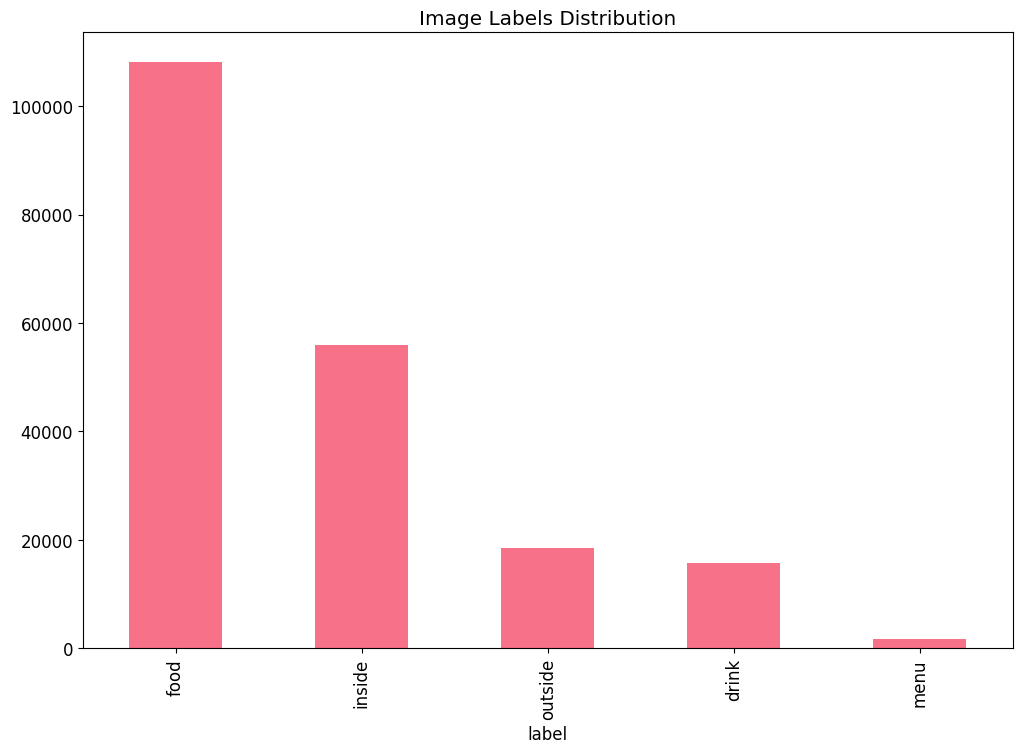

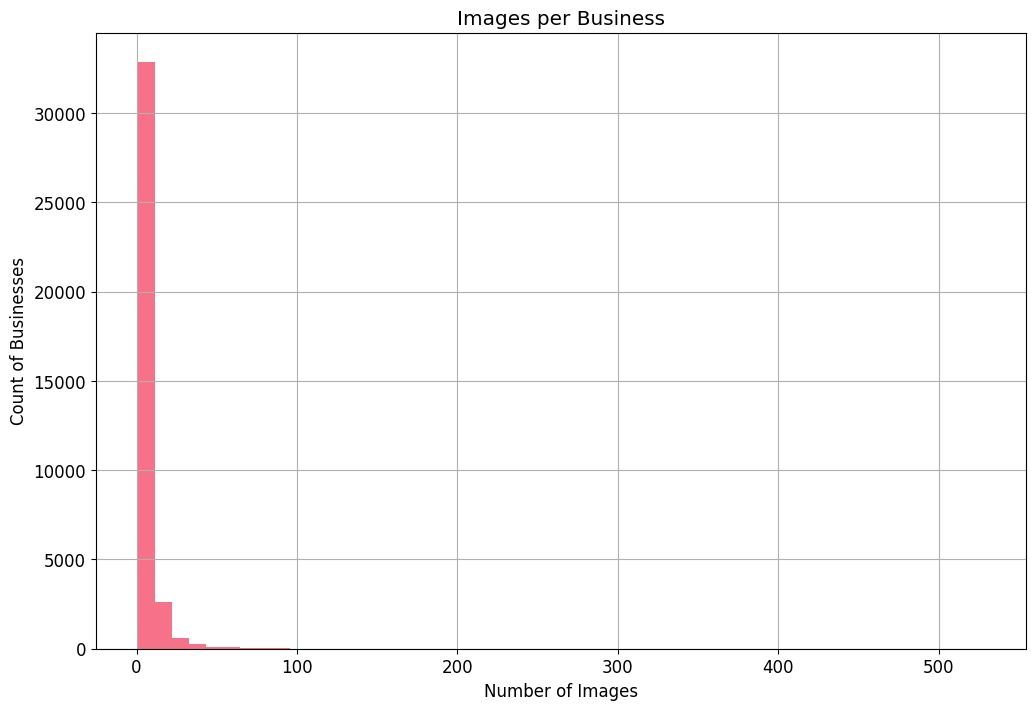

In [ ]:
import matplotlib.pyplot as plt

# Label distribution
df['label'].value_counts().plot(kind='bar', title='Image Labels Distribution')
plt.show()

# Images per business
df.groupby('business_id').size().hist(bins=50)
plt.title("Images per Business")
plt.xlabel("Number of Images")
plt.ylabel("Count of Businesses")
plt.show()


              business_id                      name  \
0  Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ   
1  mpf3x-BjTdTEA3yCZrAYPw             The UPS Store   

                           address           city state postal_code  \
0           1616 Chapala St, Ste 2  Santa Barbara    CA       93101   
1  87 Grasso Plaza Shopping Center         Affton    MO       63123   

    latitude   longitude  stars  review_count  is_open  \
0  34.426679 -119.711197    5.0             7        0   
1  38.551126  -90.335695    3.0            15        1   

                               attributes  \
0           {'ByAppointmentOnly': 'True'}   
1  {'BusinessAcceptsCreditCards': 'True'}   

                                          categories  \
0  Doctors, Traditional Chinese Medicine, Naturop...   
1  Shipping Centers, Local Services, Notaries, Ma...   

                                               hours  
0                                               None  
1  {'Monday': '0:0-0:0', 'Tues

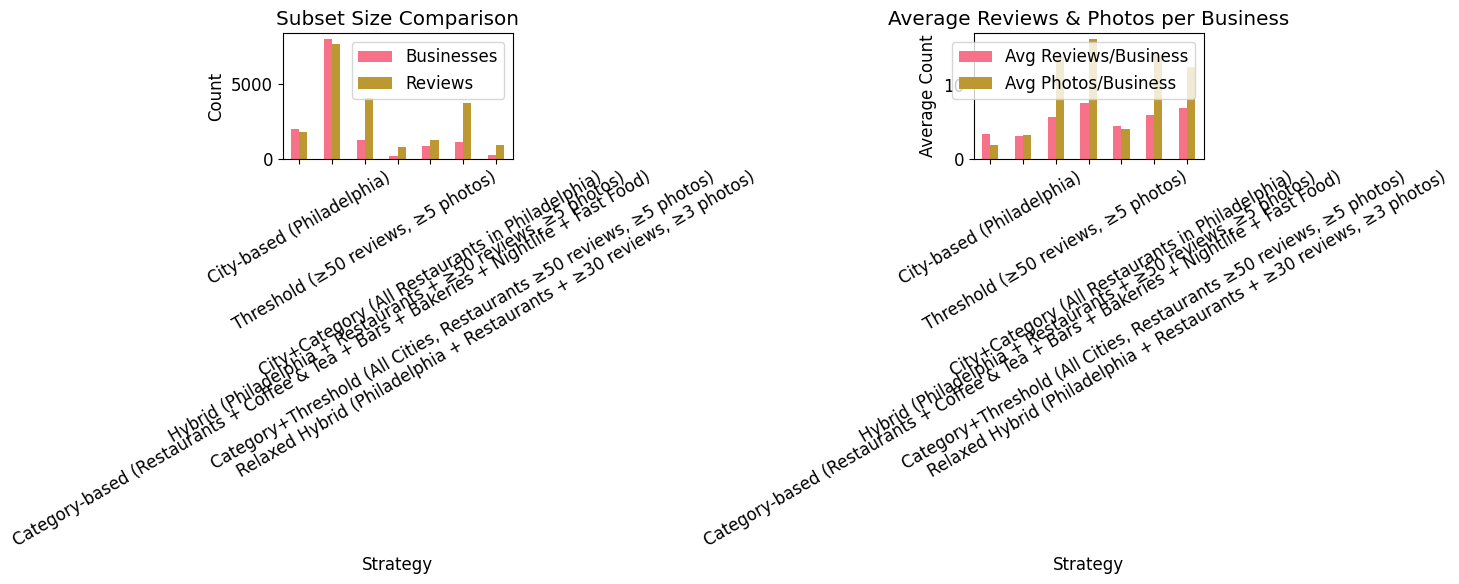

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Prepare Photo Counts ---
def add_photo_counts(business_df, photo_df):
    # Drop old photo_count column if it exists
    if "photo_count" in business_df.columns:
        business_df = business_df.drop(columns=["photo_count"])
    photo_counts = photo_df.groupby("business_id").size().reset_index(name="photo_count")
    return business_df.merge(photo_counts, on="business_id", how="left").fillna({"photo_count": 0})

# --- 2. Subset Evaluation Function ---
def evaluate_subset(business_df, review_df, name, filters):
    subset = business_df.copy()
    for f in filters:
        subset = f(subset)

    # Reviews linked to subset businesses
    reviews = review_df[review_df['business_id'].isin(subset['business_id'])]

    # Metrics
    metrics = {
        "Strategy": name,
        "Businesses": len(subset),
        "Reviews": len(reviews),
        "Avg Reviews/Business": round(reviews.groupby("business_id").size().mean(), 2) if len(subset) else 0,
        "Avg Photos/Business": round(subset['photo_count'].mean(), 2) if "photo_count" in subset.columns else 0,
        "Missing %": round(subset.isnull().mean().mean() * 100, 2)
    }
    return metrics

# --- 3. Filter Functions ---
def filter_city(city_list):
    return lambda df: df[df['city'].isin(city_list)]

def filter_category(category_keywords):
    return lambda df: df[df['categories'].notna() & df['categories'].str.contains('|'.join(category_keywords), case=False)]

def filter_threshold(min_reviews=50, min_photos=5):
    return lambda df: df[(df['review_count'] >= min_reviews) & (df['photo_count'] >= min_photos)]

# --- 0. Load Yelp Datasets ---
#business_df = pd.read_json("business.json", lines=True)
#review_df = pd.read_json("review.json", lines=True)

""" print("Business dataset loaded:", len(business_df), "records")
print("Review dataset loaded:", len(review_df), "records")
 """
# Optional: preview first few rows
print(business_df.head(2))
print(review_df.head(2))


# --- 4. Analyze Top Cities & Categories ---
top_cities = business_df['city'].value_counts().head(10)
print("Top cities:\n", top_cities, "\n")

all_cats = business_df['categories'].dropna().str.split(',').explode().str.strip()
top_categories = all_cats.value_counts().head(20)
print("Top categories:\n", top_categories, "\n")

# --- Load Photos JSON ---
photo_df = pd.read_json("photos.json", lines=True)

print("Photos dataset loaded:", len(photo_df), "records")
print(photo_df.head())


# --- 5. Merge Photos ---
business_df = add_photo_counts(business_df, photo_df)

# --- 6. Define Strategies ---
strategies = [
    ("City-based (Philadelphia)", [filter_city(["Philadelphia"])]),
    ("Category-based (Restaurants + Coffee & Tea + Bars + Bakeries + Nightlife + Fast Food)", 
     [filter_category(["Restaurants", "Coffee & Tea", "Bars", "Bakeries", "Nightlife", "Fast Food"])]),
    ("Threshold (≥50 reviews, ≥5 photos)", [filter_threshold(50, 5)]),
    ("Hybrid (Philadelphia + Restaurants + ≥50 reviews, ≥5 photos)", 
     [filter_city(["Philadelphia"]), 
      filter_category(["Restaurants"]), 
      filter_threshold(50, 5)]),
    ("City+Category (All Restaurants in Philadelphia)", [
        filter_city(["Philadelphia"]),
        filter_category(["Restaurants"])
    ]),
    ("Category+Threshold (All Cities, Restaurants ≥50 reviews, ≥5 photos)", [
        filter_category(["Restaurants"]),
        filter_threshold(50, 5)
    ]),
    ("Relaxed Hybrid (Philadelphia + Restaurants + ≥30 reviews, ≥3 photos)", [
        filter_city(["Philadelphia"]),
        filter_category(["Restaurants"]),
        filter_threshold(30, 3)
    ])
]



# --- 7. Evaluate Strategies ---
results = []
for name, filters in strategies:
    metrics = evaluate_subset(business_df, review_df, name, filters)
    results.append(metrics)

results_df = pd.DataFrame(results)
print(results_df)

# --- 8. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

results_df.plot(x="Strategy", y=["Businesses", "Reviews"], kind="bar", ax=axes[0])
axes[0].set_title("Subset Size Comparison")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

results_df.plot(x="Strategy", y=["Avg Reviews/Business", "Avg Photos/Business"], kind="bar", ax=axes[1])
axes[1].set_title("Average Reviews & Photos per Business")
axes[1].set_ylabel("Average Count")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
print(business_df['city'].unique()[:50])  # peek first 50 unique city names
print(business_df['categories'].dropna().head(20))

['Santa Barbara' 'Affton' 'Tucson' 'Philadelphia' 'Green Lane'
 'Ashland City' 'Brentwood' 'St. Petersburg' 'Nashville' "Land O' Lakes"
 'Tampa Bay' 'Indianapolis' 'Clearwater' 'Largo' 'New Orleans' 'Kenner'
 'Edmonton' 'Reno' 'Newtown' 'White House' 'Boise' 'Paoli' 'Ardmore'
 'Exton' 'Wilmington' 'Edwardsville' 'Sparks' 'Alton' 'Cherry Hill'
 'Bala Cynwyd' 'Springfield' 'Belleville' 'Carmel' 'Tampa'
 'Kennett Square' 'Plymouth Meeting' 'Harvey' 'West Chester' 'Meridian'
 'Hudson' 'Fernley' 'Williamstown' 'Pinellas Park' 'Glenolden'
 'Wesley Chapel' 'Fishers' 'Burlington' 'Troy' 'Camden' 'Plainfield']
0     Doctors, Traditional Chinese Medicine, Naturop...
1     Shipping Centers, Local Services, Notaries, Ma...
2     Department Stores, Shopping, Fashion, Home & G...
3     Restaurants, Food, Bubble Tea, Coffee & Tea, B...
4                             Brewpubs, Breweries, Food
5     Burgers, Fast Food, Sandwiches, Food, Ice Crea...
6     Sporting Goods, Fashion, Shoe Stores, Shopping...

In [25]:
for name, filters in strategies:
    subset = business_df.copy()
    for f in filters:
        subset = f(subset)
    linked_reviews = review_df[review_df['business_id'].isin(subset['business_id'])]
    print(f"Strategy: {name}")
    print(f"  Business-level data points: {len(subset)}")
    print(f"  Review-level data points:   {len(linked_reviews)}\n")

Strategy: City-based (Philadelphia)
  Business-level data points: 1967
  Review-level data points:   1750

Strategy: Category-based (Restaurants + Coffee & Tea + Bars + Bakeries + Nightlife + Fast Food)
  Business-level data points: 7961
  Review-level data points:   7621

Strategy: Threshold (≥50 reviews, ≥5 photos)
  Business-level data points: 1252
  Review-level data points:   4040

Strategy: Hybrid (Philadelphia + Restaurants + ≥50 reviews, ≥5 photos)
  Business-level data points: 159
  Review-level data points:   781

Strategy: City+Category (All Restaurants in Philadelphia)
  Business-level data points: 815
  Review-level data points:   1263

Strategy: Category+Threshold (All Cities, Restaurants ≥50 reviews, ≥5 photos)
  Business-level data points: 1118
  Review-level data points:   3734

Strategy: Relaxed Hybrid (Philadelphia + Restaurants + ≥30 reviews, ≥3 photos)
  Business-level data points: 229
  Review-level data points:   903

